In [39]:
import pandas as pd
import  matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix, ConfusionMatrixDisplay

In [27]:
df = pd.read_csv("cleaned_data.csv")
df.head()

,label,text
0,0,conoco big cowboy darren sure help know else a...
1,0,feb 01 prod sale teco gas processing sale deal...
2,0,california energy crisis california  power cr...
3,0,nom actual volume april 23 rd agree eileen pon...
4,0,eastrans nomination changes effective 8 2 00 p...


In [28]:
df = df.dropna(subset=["label"])
df["text"] = df["text"].fillna("").astype(str).str.lower()

In [29]:
df["label"] = df["label"].astype(str).str.lower().str.strip()

In [30]:
X = df["text"]
y = df["label"]

In [31]:
print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (2998, 2)
  label                                               text
0     0  conoco big cowboy darren sure help know else a...
1     0  feb 01 prod sale teco gas processing sale deal...
2     0  california energy crisis california  power cr...
3     0  nom actual volume april 23 rd agree eileen pon...
4     0  eastrans nomination changes effective 8 2 00 p...


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)


In [34]:
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [35]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)


In [36]:
model.fit(X_train_vec, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to u

In [37]:
y_pred = model.predict(X_test_vec)

In [38]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))


Accuracy: 0.9683333333333334

Classification Report:
              precision    recall  f1-score   support

         Ham       1.00      0.94      0.97       300
        Spam       0.94      1.00      0.97       300

    accuracy                           0.97       600
   macro avg       0.97      0.97      0.97       600
weighted avg       0.97      0.97      0.97       600



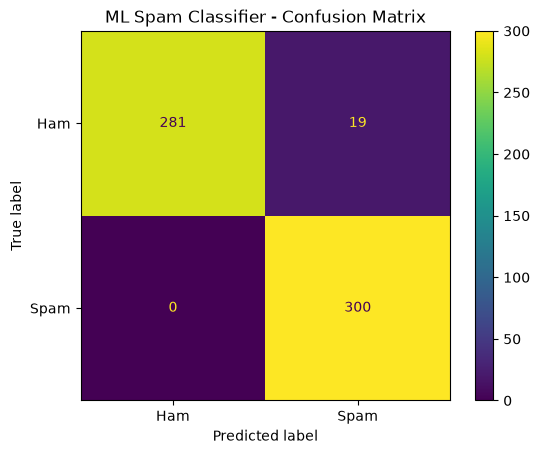

In [41]:
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred),
    display_labels=["Ham", "Spam"]
).plot()
plt.title("ML Spam Classifier - Confusion Matrix")
plt.show()


In [42]:
messages = [
    "Congratulations! You have won a free prize",
    "Hey, are we meeting today?"
]

messages_vec = vectorizer.transform(messages)
predictions = model.predict(messages_vec)
probabilities = model.predict_proba(messages_vec)[:, 1]

for message, prediction, probability in zip(
    messages, predictions, probabilities
):
    print("\nMessage:", message)
    print("Prediction:", "Spam" if prediction == 1 else "Ham")
    print("Spam probability:", round(probability, 4))



Message: Congratulations! You have won a free prize
Prediction: Ham
Spam probability: 0.7903

Message: Hey, are we meeting today?
Prediction: Ham
Spam probability: 0.673


In [47]:
model.predict_proba(messages_vec),model.predict_proba(messages_vec)[:,1]

(array([[0.2097418 , 0.7902582 ],
        [0.32698564, 0.67301436]]),
 array([0.7902582 , 0.67301436]))